In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
features = pd.read_csv('D:/project/data/features.csv')
train = pd.read_csv('D:/project/data/train.csv')
stores = pd.read_csv('D:/project/data/stores.csv')

#TABLES SHAPE, COLUMNS and MISSING VALUES
print("Shape of features : ", features.shape,"Shape of train : ", train.shape,"Shape of stores : ", stores.shape)
print("Info of features : ", features.info,"Info of train : ", train.info,"Info of stores : ", stores.info)
print("Missing values in features : ", features.isna().sum(),"Missing values in train : ", train.isna().sum(),"Missing values in stores : ", stores.isna().sum())

Shape of features :  (8190, 12) Shape of train :  (421570, 5) Shape of stores :  (45, 3)
Info of features :  <bound method DataFrame.info of       Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0         1  2010-02-05        42.31       2.572        NaN        NaN   
1         1  2010-02-12        38.51       2.548        NaN        NaN   
2         1  2010-02-19        39.93       2.514        NaN        NaN   
3         1  2010-02-26        46.63       2.561        NaN        NaN   
4         1  2010-03-05        46.50       2.625        NaN        NaN   
...     ...         ...          ...         ...        ...        ...   
8185     45  2013-06-28        76.05       3.639    4842.29     975.03   
8186     45  2013-07-05        77.50       3.614    9090.48    2268.58   
8187     45  2013-07-12        79.37       3.614    3789.94    1827.31   
8188     45  2013-07-19        82.84       3.737    2961.49    1047.07   
8189     45  2013-07-26        76.06       3.

### MERGING ALL THE DATASEST INTO SINGLE MASTER TABLE

In [3]:
df = train.merge(stores, on = ['Store'], how = 'left').merge(features, on = ['Store','Date'], how = 'left', suffixes = ('_train','_feat'))
df['ID'] = range(1, len(df)+1)
col1 = df.pop('ID')
df.insert(0, 'ID', col1)
df['IsHoliday'] = df['IsHoliday_train'].combine_first(df['IsHoliday_feat'])
df = df.drop(columns=['IsHoliday_train','IsHoliday_feat'])
col2 = df.pop('IsHoliday')
df.insert(9, 'IsHoliday', col2)
df.head()

,ID,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,IsHoliday,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,1,2010-02-05,24924.50,A,151315,42.31,2.572,False,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,2,1,1,2010-02-12,46039.49,A,151315,38.51,2.548,True,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,3,1,1,2010-02-19,41595.55,A,151315,39.93,2.514,False,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,4,1,1,2010-02-26,19403.54,A,151315,46.63,2.561,False,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,5,1,1,2010-03-05,21827.90,A,151315,46.50,2.625,False,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


### CONVERTING DATE INTO DATETIME AND EXTRACT YEAR, MONTH and WEEK

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df.head()

,ID,Store,Dept,Date,Weekly_Sales,Type,Size,Temperature,Fuel_Price,IsHoliday,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Day
0,1,1,1,2010-02-05,24924.50,A,151315,42.31,2.572,False,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,2010,2,5
1,2,1,1,2010-02-12,46039.49,A,151315,38.51,2.548,True,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,2010,2,12
2,3,1,1,2010-02-19,41595.55,A,151315,39.93,2.514,False,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,2010,2,19
3,4,1,1,2010-02-26,19403.54,A,151315,46.63,2.561,False,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,2010,2,26
4,5,1,1,2010-03-05,21827.90,A,151315,46.50,2.625,False,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,2010,3,5


### CHECK MISSING VALUES IN MARKDOWNS AND FILL WITH 0

In [5]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
print(df[markdown_cols].isna().sum())
print(df[markdown_cols].fillna(0))
print(df[markdown_cols].isna().sum())

MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64
        MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5
0            0.00       0.00       0.00       0.00       0.00
1            0.00       0.00       0.00       0.00       0.00
2            0.00       0.00       0.00       0.00       0.00
3            0.00       0.00       0.00       0.00       0.00
4            0.00       0.00       0.00       0.00       0.00
...           ...        ...        ...        ...        ...
421565    4556.61      20.64       1.50    1601.01    3288.25
421566    5046.74       0.00      18.82    2253.43    2340.01
421567    1956.28       0.00       7.89     599.32    3990.54
421568    2004.02       0.00       3.18     437.73    1537.49
421569    4018.91      58.08     100.00     211.94     858.33

[421570 rows x 5 columns]
MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64


### TOP 5 STORES WITH THE HIGHEST TOTAL SALES.

In [6]:
df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(5)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64

### TOP 5 WORST STORES (lowest average sale)

In [7]:
df.groupby('Store')['Weekly_Sales'].mean().sort_values().head(5)

Store
5     5053.415813
33    5728.414053
44    6038.929814
3     6373.033983
38    7492.478460
Name: Weekly_Sales, dtype: float64

### NUMBER OF UNIQUE DEPARTMENTS PER STORE

In [8]:
df.groupby('Store')['Dept'].nunique().head()

Store
1    77
2    78
3    72
4    78
5    72
Name: Dept, dtype: int64

### PLOTTING TOTAL SALES TREND OVER TIME

<Axes: title={'center': 'Weekly Sales Trend'}, xlabel='Date'>

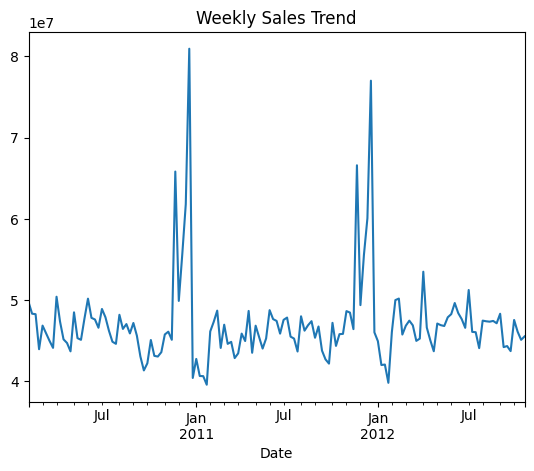

In [9]:
sales_trend = df.groupby('Date')['Weekly_Sales'].sum()
sales_trend.plot(title = 'Weekly Sales Trend')

### COMPARING AVERAGE SALES BY STORE TYPE (bar plot)

<Axes: xlabel='Type', ylabel='Weekly_Sales'>

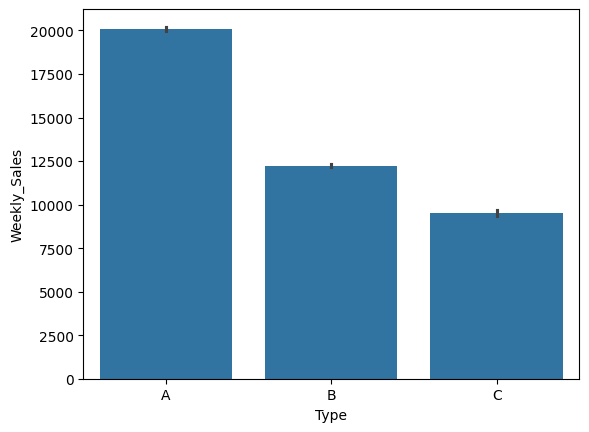

In [10]:
sns.barplot(x='Type', y='Weekly_Sales', data=df, estimator='mean')

### COMPARING SALES BY STORE SIZE QUARTILES

<Axes: xlabel='Size_Category', ylabel='Weekly_Sales'>

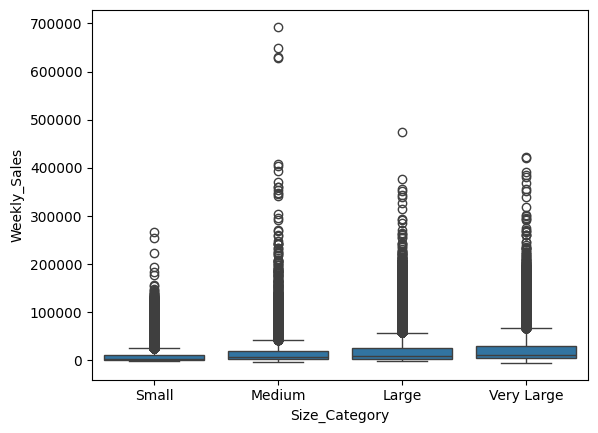

In [11]:
df['Size_Category'] = pd.qcut(df['Size'], 4, labels=['Small', 'Medium', 'Large', 'Very Large'])
sns.boxplot(x='Size_Category', y='Weekly_Sales', data=df)

### SALES DISTRIBUTION OF HOLIDAYS vs NON-HOLIDAYS 

<Axes: xlabel='IsHoliday', ylabel='Weekly_Sales'>

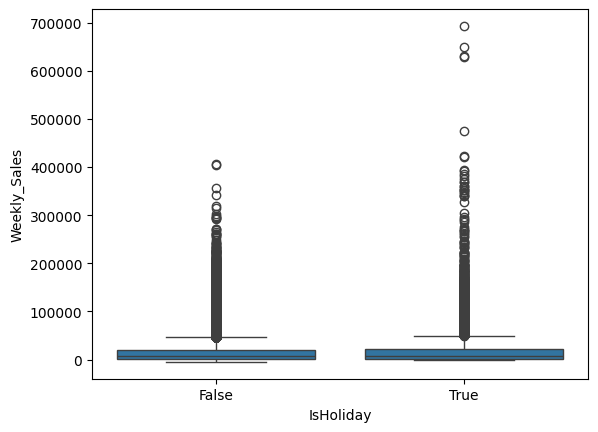

In [12]:
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df)

### MONTHLY SALES AVERAGE AND PLOTTING THE PATTERN

<Axes: xlabel='Month'>

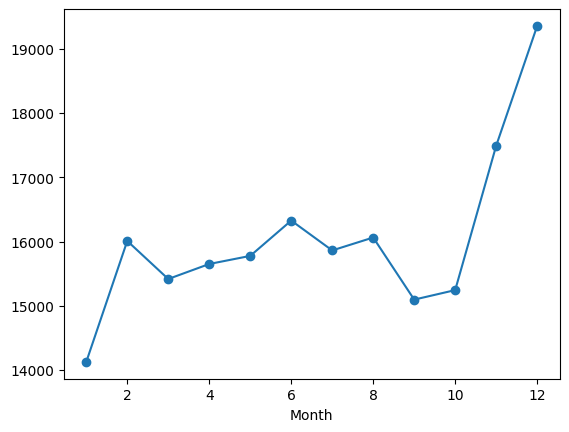

In [13]:
monthly = df.groupby('Month')['Weekly_Sales'].mean()
monthly.plot(marker='o')

### CORRELATION HEATMAP OF WEEKLY SALES vs EXTERNAL FACTORS

<Axes: >

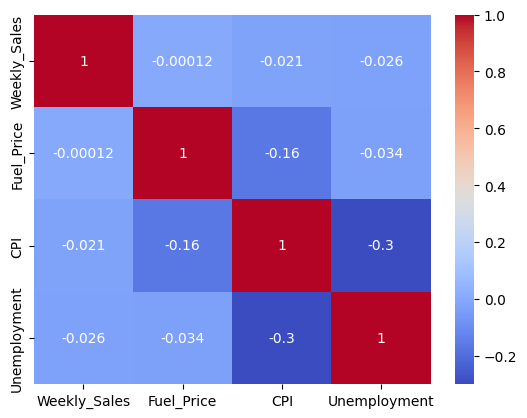

In [14]:
corr = df[['Weekly_Sales', 'Fuel_Price', 'CPI', 'Unemployment']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

### 10 DEPARTMENTS WHICH CONTRIBUTED MOST SALES

In [15]:
df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)

Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
40    2.889360e+08
2     2.806112e+08
91    2.167817e+08
13    1.973216e+08
8     1.942808e+08
Name: Weekly_Sales, dtype: float64

### STORE WITH MOST UNSTABLE SALES PATTERN(max variance in sales)

In [16]:
df.groupby('Store')['Weekly_Sales'].var().sort_values(ascending=False).head(1)

Store
14    1.362431e+09
Name: Weekly_Sales, dtype: float64

### COMPARING SALES BY YEAR ACROSS ALL THE STORES

<Axes: xlabel='Year'>

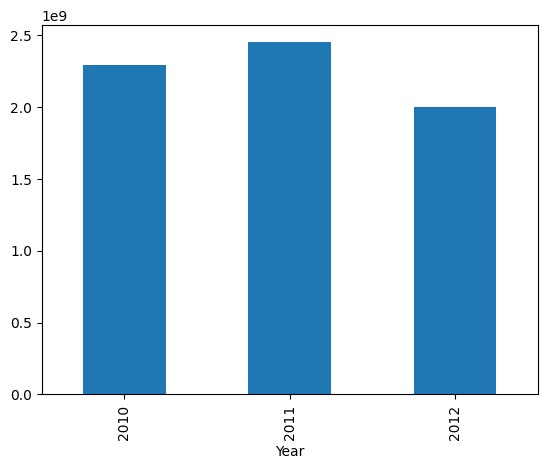

In [17]:
df.groupby('Year')['Weekly_Sales'].sum().plot(kind='bar')

### MEAN HOLIDAY VS NON-HOLIDAY SALES PER YEAR

<Axes: xlabel='Year'>

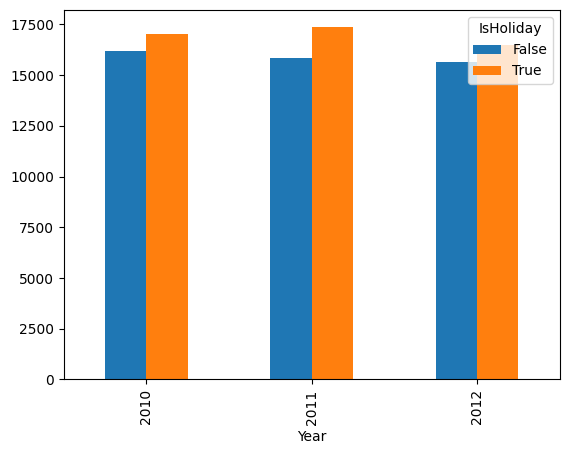

In [22]:
df.groupby(['Year','IsHoliday'])['Weekly_Sales'].mean().unstack().plot(kind='bar')

### PIVOT TABLE -> (Store type x Year) AVERAGE SALES

In [24]:
pd.pivot_table(df,values='Weekly_Sales', index='Year', columns='Type', aggfunc='mean')

Type,A,B,C
Year,,,
2010,20327.226574,12627.241607,9571.743733
2011,20111.476693,12177.025551,9402.674708
2012,19832.335496,11877.700600,9602.105782


### TOTAL MARKDOWN EFFECT(1-5) PLOT vs SALES

<Axes: xlabel='Total_Markdown', ylabel='Weekly_Sales'>

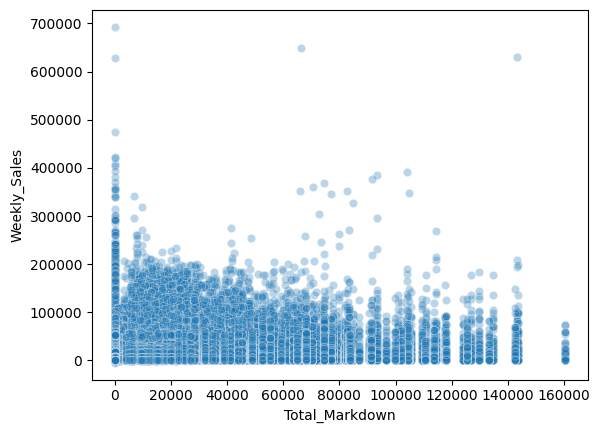

In [28]:
df['Total_Markdown'] = df[markdown_cols].sum(axis=1)  #axis=0 = down the rows (column-wise sum)
                                                      #axis=1 = across the columns (row-wise sum)
sns.scatterplot(x='Total_Markdown', y='Weekly_Sales', data=df, alpha=0.3)

### TOP 5 DEPARTMENTS IN STORE 20

In [30]:
df[df['Store']==20].groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False).head(5)

Dept
92    23542625.04
95    21537795.62
38    15759345.93
90    13707777.99
72    13154550.44
Name: Weekly_Sales, dtype: float64

### MONTH WITH HIGHEST AVERAGE SALES IN EACH YEAR

In [34]:
df.groupby(['Year','Month'])['Weekly_Sales'].mean().unstack().idxmax(axis=1)

Year
2010    12
2011    12
2012     6
dtype: int32

### DAY WITH HIGHEST AVERAGE SALES

In [36]:
df['DayOfWeek'] = df['Date'].dt.day_name()
df.groupby('DayOfWeek')['Weekly_Sales'].mean().sort_values(ascending=False)

DayOfWeek
Friday    15981.258123
Name: Weekly_Sales, dtype: float64

### PLOTTING SALES DISTRIBUTION BY STORES TYPE & HOLIDAY FLAG (boxplot)

<Axes: xlabel='Type', ylabel='Weekly_Sales'>

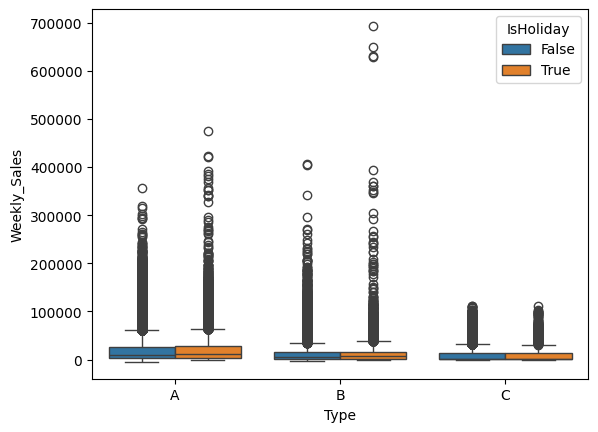

In [37]:
sns.boxplot(x='Type', y='Weekly_Sales', hue='IsHoliday', data=df)

<Axes: xlabel='Date'>

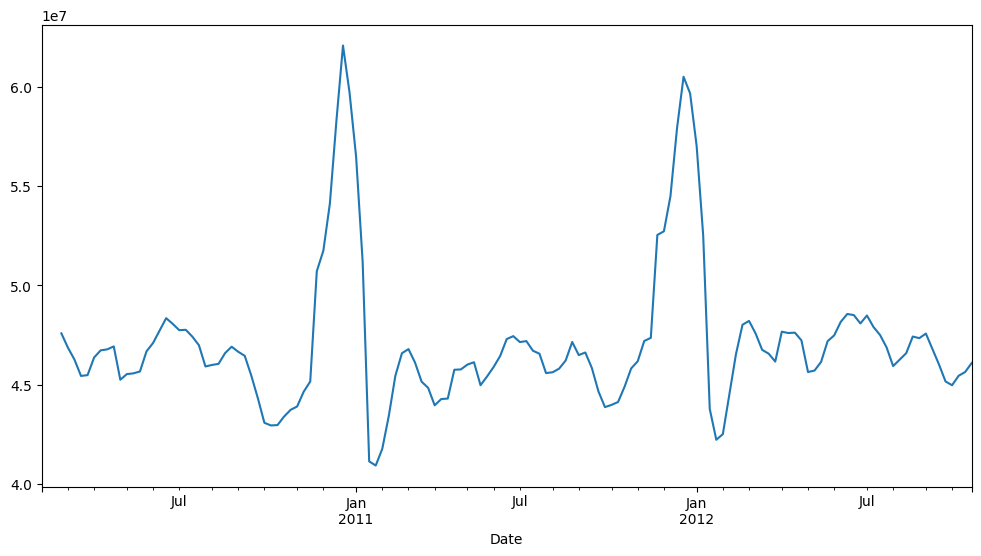

In [40]:
df.groupby('Date')['Weekly_Sales'].sum().rolling(4).mean().plot(figsize=(12,6))

## SUMMARY TABLES
### (Store, Type, Size, Avg Sales, Total Sales)   store-level summary table
### (Store, Dept, Avg Sales, Total Sales)   dept-level summary table
### (Year, Month, Sales)   monthly sales summary
### (Store x Year x Holiday Sales)   holiday impact table

In [44]:
store_summary = df.groupby(['Store', 'Type', 'Size'])['Weekly_Sales'].agg(['mean', 'sum']).reset_index()
dept_summary = df.groupby(['Store', 'Dept'])['Weekly_Sales'].agg(['mean', 'sum']).reset_index()
monthly_sales = df.groupby(['Year', 'Month'])['Weekly_Sales'].sum().reset_index()
holiday_sales = df.groupby(['Store', 'Year', 'IsHoliday'])['Weekly_Sales'].mean().reset_index()

### EXPORTING CLEANED TABLES FOR PowerBI

In [48]:
store_summary.to_csv('store_summary.csv', index=False)
dept_summary.to_csv('dept_summary.csv', index=False)
monthly_sales.to_csv('monthly_sales.csv', index=False)
holiday_sales.to_csv('holiday_sales.csv', index=False)